In [1]:
import pandas as pd

df = pd.read_csv("listings.csv")

df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,821198084644106078,https://www.airbnb.com/rooms/821198084644106078,20250926170004,2025-09-27,city scrape,Bright and Peaceful Leblon Loft,Welcome! Come relax in our bright and stylish ...,Beautiful tree lined street just 3 blocks from...,https://a0.muscache.com/pictures/hosting/Hosti...,84350716,...,4.94,4.99,4.85,NaN,f,1,1,0,0,2.72
1,821198370698658112,https://www.airbnb.com/rooms/821198370698658112,20250926170004,2025-09-27,city scrape,Copacabana 100% reformado.,Guarantee of a safe and quality stay! <br /><...,"Copacabana, in the part near the neighborhood ...",https://a0.muscache.com/pictures/miso/Hosting-...,4347269,...,NaN,NaN,NaN,NaN,f,2,2,0,0,NaN
2,821200521820144734,https://www.airbnb.com/rooms/821200521820144734,20250926170004,2025-09-26,city scrape,hambiente familia,Relax with the whole family in this quiet acco...,NaN,https://a0.muscache.com/pictures/7485ea61-a28a...,499903412,...,NaN,NaN,NaN,NaN,t,2,1,1,0,NaN
3,821213014263313420,https://www.airbnb.com/rooms/821213014263313420,20250926170004,2025-09-27,previous scrape,Amazing en suite bedroom Leblon,"Kick back and relax in this calm, stylish spac...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,449763717,...,5.00,5.00,4.67,NaN,f,2,1,1,0,0.10
4,821223043903573522,https://www.airbnb.com/rooms/821223043903573522,20250926170004,2025-09-27,city scrape,Incrível apartamento frente mar,Amazing 1-bedroom apartment facing the sea. Co...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,25961210,...,5.00,5.00,5.00,NaN,f,1,1,0,0,0.60


In [2]:
cidade = "Rio de Janeiro"
print(f"Cidade analisada: {cidade}")

Cidade analisada: Rio de Janeiro


In [3]:
#colunas, linhas
df.shape

(43068, 79)

In [4]:

#colunas
df.columns
#Tipo de dado de cada coluna
df.dtypes

id                                                int64
listing_url                                         str
scrape_id                                         int64
last_scraped                                        str
source                                              str
                                                 ...   
calculated_host_listings_count                    int64
calculated_host_listings_count_entire_homes       int64
calculated_host_listings_count_private_rooms      int64
calculated_host_listings_count_shared_rooms       int64
reviews_per_month                               float64
Length: 79, dtype: object

In [5]:
#Ranking dos que possuem mais valores nulos
df.isnull().sum().sort_values(ascending=False)

license                                         43068
calendar_updated                                43068
neighbourhood_group_cleansed                    43068
neighbourhood                                   26738
neighborhood_overview                           26738
                                                ...  
instant_bookable                                    0
calculated_host_listings_count                      0
calculated_host_listings_count_entire_homes         0
calculated_host_listings_count_private_rooms        0
calculated_host_listings_count_shared_rooms         0
Length: 79, dtype: int64

In [6]:
colunas_relevantes = [
    'price',
    'room_type', 
    'neighbourhood_cleansed',
    'accommodates',
    'number_of_reviews', 
    'reviews_per_month',  
    'amenities'                   
]

In [7]:
proxy = 'number_of_reviews'

In [8]:
df[colunas_relevantes].info()

<class 'pandas.DataFrame'>
RangeIndex: 43068 entries, 0 to 43067
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   price                   38670 non-null  str    
 1   room_type               43068 non-null  str    
 2   neighbourhood_cleansed  43068 non-null  str    
 3   accommodates            43068 non-null  int64  
 4   number_of_reviews       43068 non-null  int64  
 5   reviews_per_month       33882 non-null  float64
 6   amenities               43068 non-null  str    
dtypes: float64(1), int64(2), str(4)
memory usage: 2.3 MB


### Tratamento de PRICE
**Justificativa de Price:** Realizei o tratamento dos dados na coluna PRICE, que possuia caracteres especiais. Os removi e converti a coluna em float para melhorar a ánalise com base nos preços

In [9]:
df['price'].head(10)

0      $580.00
1    $1,900.00
2      $700.00
3          NaN
4      $500.00
5      $461.00
6          NaN
7      $281.00
8      $950.00
9      $450.00
Name: price, dtype: str

In [10]:
df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)

In [11]:
df['price'].head(10)

0     580.0
1    1900.0
2     700.0
3       NaN
4     500.0
5     461.0
6       NaN
7     281.0
8     950.0
9     450.0
Name: price, dtype: float64

In [12]:
df[colunas_relevantes].head(5)

,price,room_type,neighbourhood_cleansed,accommodates,number_of_reviews,reviews_per_month,amenities
0,580.0,Entire home/apt,Leblon,4,86,2.72,"[""Hangers"", ""Hot water kettle"", ""Wine glasses""..."
1,1900.0,Entire home/apt,Copacabana,2,0,NaN,"[""Smoking allowed"", ""TV"", ""Kitchen"", ""Washer"",..."
2,700.0,Entire home/apt,Pavuna,4,0,NaN,"[""BBQ grill"", ""Exterior security cameras on pr..."
3,NaN,Private room,Leblon,2,3,0.10,"[""Essentials"", ""Hair dryer"", ""Cooking basics"",..."
4,500.0,Entire home/apt,Barra da Tijuca,4,11,0.60,"[""Outdoor shower"", ""Pool"", ""Free parking on pr..."


In [13]:
df['price'].isnull().sum()

np.int64(4398)

In [14]:
df = df.dropna(subset=['price']).copy()

In [15]:
df['price'].isnull().sum()

np.int64(0)

### Transformação de Amenidades
**Justificativa das Amenidades:** Optei por extrair as 5 amenidades mais frequentes na base de dados pois elas representam a infraestrutura básica e o padrão mínimo esperado pela maioria dos hóspedes

In [16]:
# 1. Removemos os colchetes e aspas da string usando regex
amenities_limpas = df['amenities'].str.replace(r'[\[\]"]', '', regex=True)

# 2. Separamos o texto por vírgulas para criar uma lista
amenities_listas = amenities_limpas.str.split(', ')

# 3. O 'explode' separa cada item da lista em uma linha temporária.
ranking_amenidades = amenities_listas.explode().value_counts()

# Mostrando amenidades que mais aparecem no Rio de Janeiro
display(ranking_amenidades.head(5))

amenities
Kitchen                  35206
Wifi                     34973
Hot water                25261
Dishes and silverware    24148
Air conditioning         24106
Name: count, dtype: int64

In [17]:
top_amenidades = ranking_amenidades.head(5).index.tolist()

import re
colunas_novas = []

for amenidade in top_amenidades:
    nome_limpo = re.sub(r'[^a-zA-Z0-9]', '_', amenidade.lower())
    nome_coluna = f'has_{nome_limpo}'
    
    df[nome_coluna] = df['amenities'].str.contains(amenidade, case=False, na=False).astype(int)
    
    colunas_novas.append(nome_coluna)

df[['price', 'accommodates'] + colunas_novas].head(10)    

,price,accommodates,has_kitchen,has_wifi,has_hot_water,has_dishes_and_silverware,has_air_conditioning
0,580.0,4,1,1,1,1,0
1,1900.0,2,1,1,0,0,1
2,700.0,4,1,0,0,0,1
4,500.0,4,1,1,0,0,1
5,461.0,6,1,1,1,1,1
7,281.0,2,1,1,1,1,0
8,950.0,2,1,1,1,1,1
9,450.0,4,0,1,1,0,0
10,1000.0,6,1,1,1,1,1
11,980.0,3,1,1,1,1,1


In [18]:
resumo = df.groupby('room_type').agg({
    'price': ['mean', 'median'],
    'number_of_reviews': 'mean',
    'accommodates': 'mean'
})
print(resumo)

                      price        number_of_reviews accommodates
                       mean median              mean         mean
room_type                                                        
Entire home/apt  800.152831  350.0         29.843272     4.342234
Hotel room       619.800000  470.0         56.400000     2.933333
Private room     375.078981  205.0         17.672709     2.327003
Shared room      199.075949  105.0          9.377215     4.708861


In [19]:
df.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False).head(5)

neighbourhood_cleansed
Estácio        7003.148649
Joá            6878.132075
São Conrado    3000.919162
Anchieta       2531.000000
Itanhangá      2528.747191
Name: price, dtype: float64

In [23]:
# Preço por pessoa
df['price_per_person'] = df['price'] / df['accommodates']

# Faixa de preço
df['faixa_preco'] = pd.cut(df['price'],
    bins=[0, 150, 400, float('inf')],
    labels=['Barato', 'Médio', 'Caro'])

# Superhost como binário
df['is_superhost'] = (df['host_is_superhost'] == 't').astype(int)

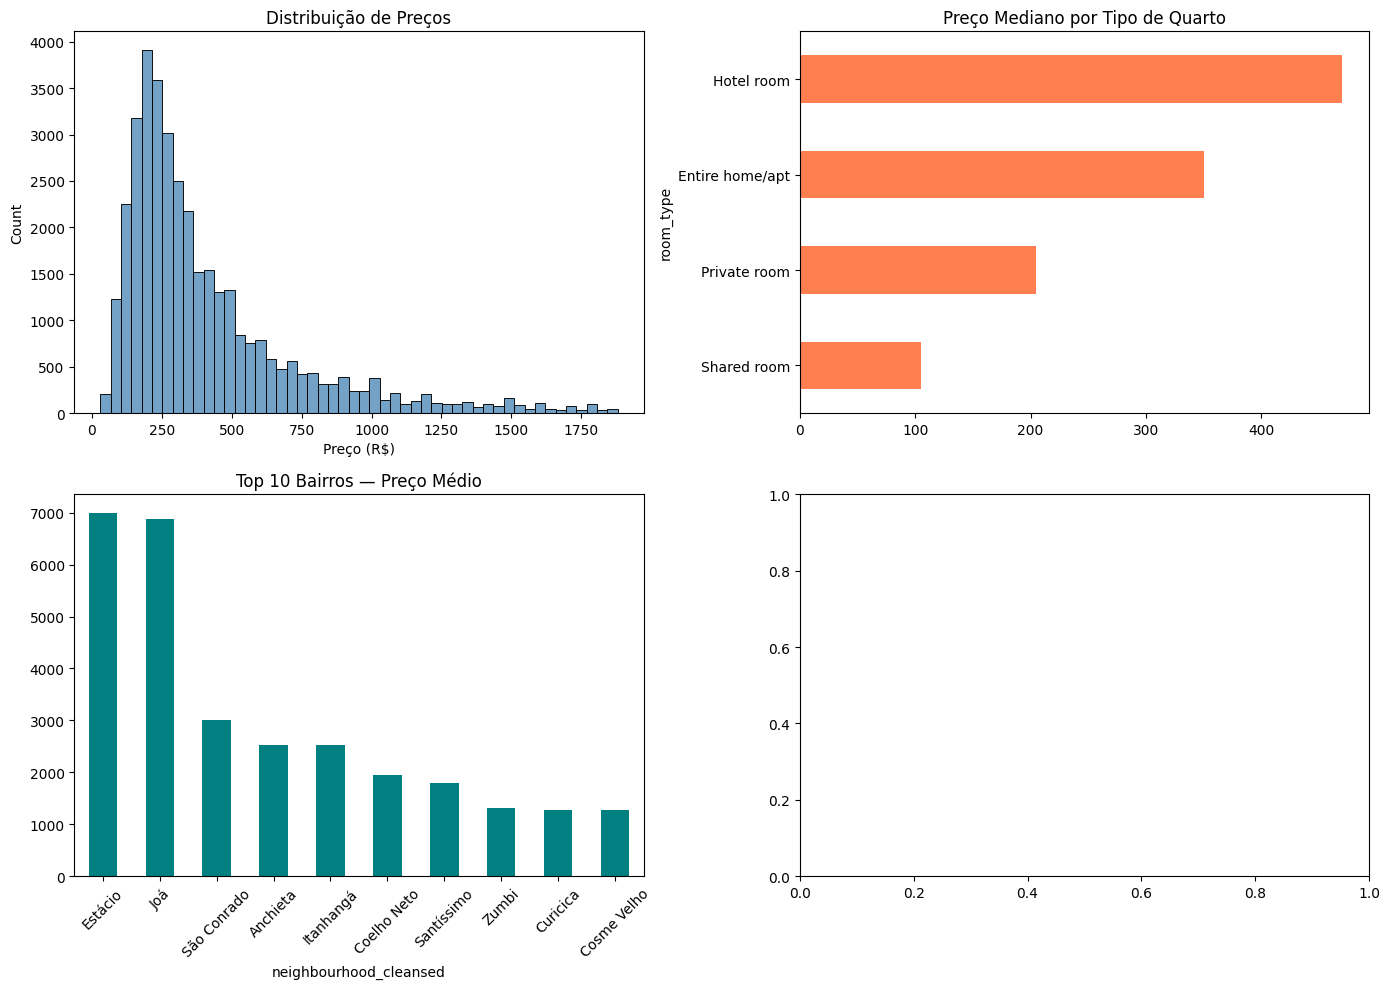

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribuição de preços (sem outliers)
df_sem_outlier = df[df['price'] < df['price'].quantile(0.95)]
sns.histplot(df_sem_outlier['price'], bins=50, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Distribuição de Preços')
axes[0,0].set_xlabel('Preço (R$)')

# 2. Preço médio por tipo de quarto
medias = df.groupby('room_type')['price'].median().sort_values()
medias.plot(kind='barh', ax=axes[0,1], color='coral')
axes[0,1].set_title('Preço Mediano por Tipo de Quarto')

# 3. Top 10 bairros mais caros
top_bairros = df.groupby('neighbourhood_cleansed')['price'].mean().nlargest(10)
top_bairros.plot(kind='bar', ax=axes[1,0], color='teal')
axes[1,0].set_title('Top 10 Bairros — Preço Médio')
axes[1,0].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()